## Preperation

In [1]:
import os
import torch
import torch.nn as nn
from Model import EEGModel
from Data import EEG0012017DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
DATA_PATH = '.\\RawDataset\\'
CACHE_PATH = '.\\Dataset\\'
MODEL_PATH = '.\\Models\\'

CRITERION = nn.CrossEntropyLoss()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ARCHITECTURES = ['EEGNet', 'DeepConvNet', 'ShallowFBCSPNet', 'EEGNeX', 'CTNet', 'Deep4Net']

SUBJECT_COUNT = 15
LEARNING_RATE = 0.01
P_LEARNING_RATE = 0.02
BATCH_SIZE = 8
P_BATCH_SIZE = 16
EPOCH_NUM = 25
P_EPOCH_NUM = 20
RANDOM_SEED = 42
SPLIT = (0.8, 0.1, 0.1)

## Evaluation

In [3]:
def plot_learning_curves(train_losses, val_losses, title_exp='Loss'):
    """
    Plots the training and validation loss curves over epochs.
    
    Args:
        train_losses (list of floats): Loss values for the training set per epoch.
        val_losses (list of floats): Loss values for the validation set per epoch.
        save_path (str, optional): If provided, saves the plot to this file path.
    """
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    
    plt.title(f'Training and Validation {title_exp}', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # Force x-axis to use integer ticks for epochs
    plt.xticks(epochs) 
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)

    plt.show()

In [10]:
def plot_confusion_matrix(model, data_loader, class_names, title='Confusion Matrix'):

    model.model.eval()
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for X, y in data_loader:
            X = X.to(model.device)
            y = y.to(model.device)

            outputs = model.model(X)
            predictions = torch.argmax(outputs, dim=1)
            all_targets.extend(y.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    all_targets = np.array(all_targets)
    all_predictions = np.array(all_predictions)

    cm = confusion_matrix(all_targets, all_predictions, labels=np.arange(len(class_names)))
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=True)
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

    return cm

In [ ]:
def plot_model_performance(labels, test_means, test_vars, val_means, val_vars):
    test_std = np.sqrt(np.array(test_vars))
    val_std = np.sqrt(np.array(val_vars))
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width / 2, test_means, width, yerr=test_std, capsize=5, label="Test")
    ax.bar(x + width / 2, val_means, width, yerr=val_std, capsize=5, label="Validation")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy")
    ax.set_title("Model Performance Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()

    ax.grid(axis="y", alpha=0.3)
    all_values = np.concatenate([
        np.array(test_means) - test_std,
        np.array(test_means) + test_std,
        np.array(val_means) - val_std,
        np.array(val_means) + val_std
    ])

    y_min = all_values.min()
    y_max = all_values.max()

    margin = (y_max - y_min) * 0.15

    ax.set_ylim(y_min - margin, y_max + margin)
    plt.tight_layout()
    plt.show()

## DataLoading

In [6]:
data_loader_factory = EEG0012017DataLoader(
    data_path=DATA_PATH, 
    cache_path=CACHE_PATH, 
    batch_size=BATCH_SIZE,
    split_ratios=SPLIT
)

classes = data_loader_factory.get_class_names()
print(f"Target Classes: {classes}")

Target Classes: ['Elbow Flexion', 'Elbow Extension', 'Supination', 'Pronation', 'Hand Open', 'Hand Close', 'Rest']


## Basic Training 


------ Setting up training for Subject 1 ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Selected Architecture: EEGNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 8, 61, 769]             512
       BatchNorm2d-2           [-1, 8, 61, 769]              16
            Conv2d-3           [-1, 16, 1, 769]             976
       BatchNorm2d-4           [-1, 16, 1, 769]              32
               ELU-5           [-1, 16, 1, 769]               0
         AvgPool2d-6           [-1, 16, 1, 192]               0
           Dropout-7           [-1, 16, 1, 192]               0
            Conv2d-8           [-1, 16, 1, 192]             256
            Conv2d-9           [-1, 16, 1, 192]             256
      BatchNorm2d-10           [-1, 16, 1, 192]              32
              ELU-11           [-1, 16, 1, 192]               0
   

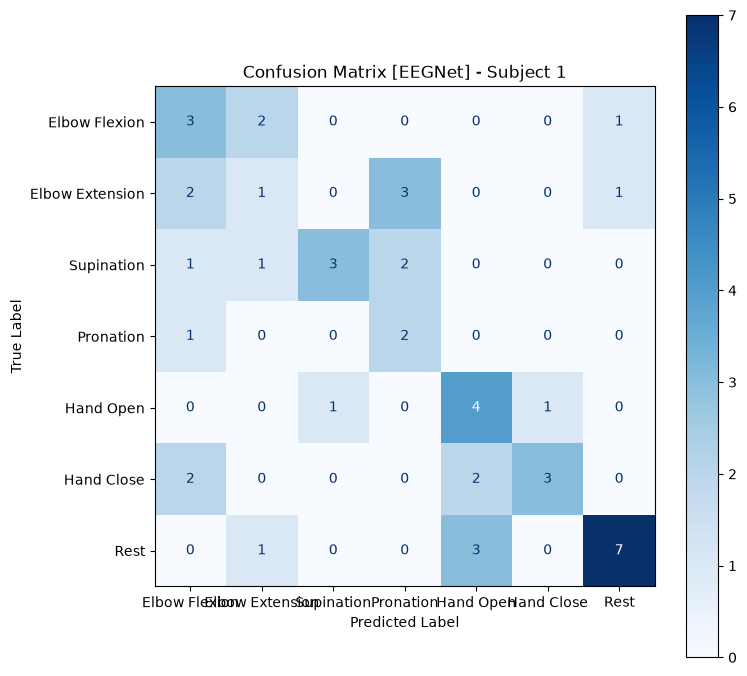

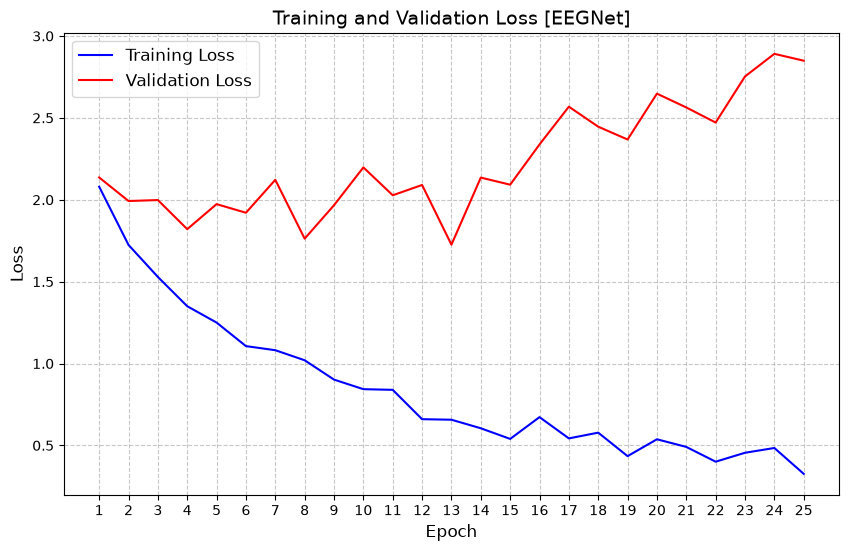

Selected Architecture: DeepConvNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100, 1, 72]             200
    

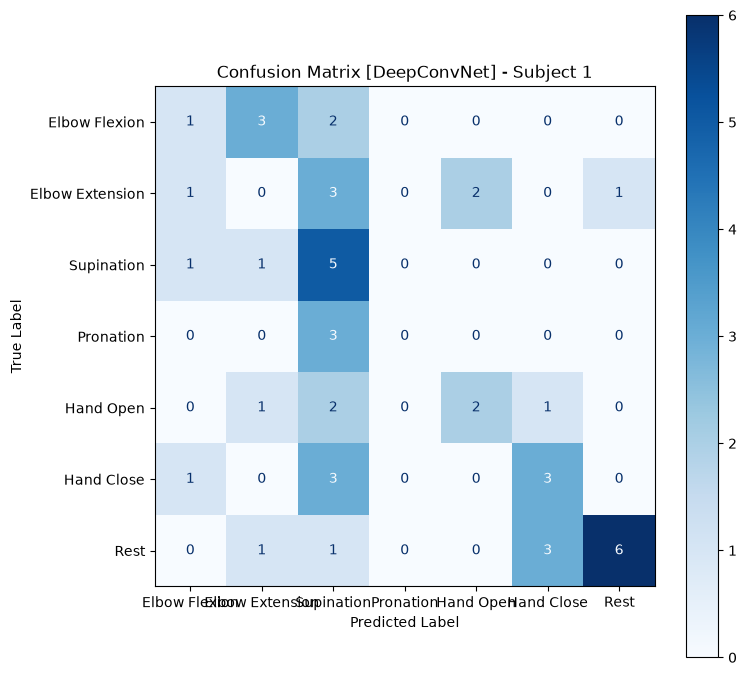

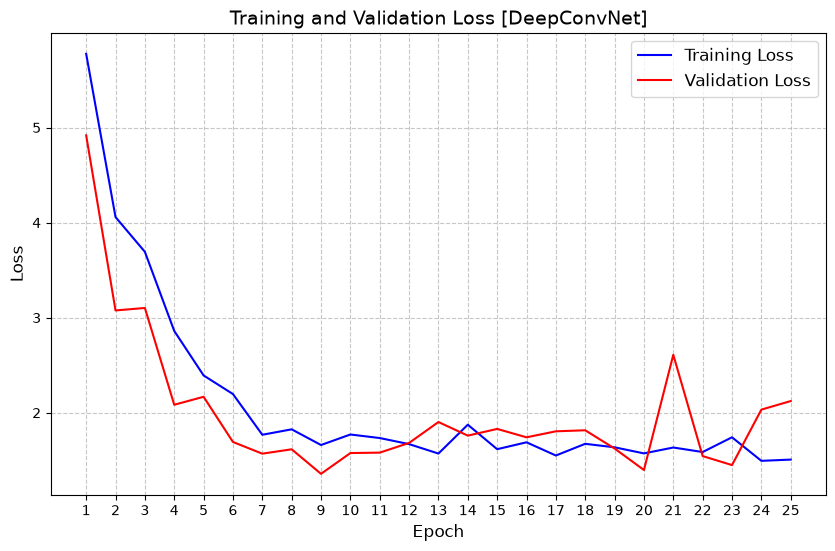

Selected Architecture: ShallowFBCSPNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 40, 61, 745]           1,000
            Conv2d-2           [-1, 40, 1, 745]          97,600
       BatchNorm2d-3           [-1, 40, 1, 745]              80
        Expression-4           [-1, 40, 1, 745]               0
         AvgPool2d-5            [-1, 40, 1, 45]               0
        Expression-6            [-1, 40, 1, 45]               0
           Dropout-7            [-1, 40, 1, 45]               0
           Flatten-8                 [-1, 1800]               0
            Linear-9                    [-1, 7]          12,607
Total params: 111,287
Trainable params: 111,287
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.18
Forward/backward pass size (MB): 14.61
Params size (MB): 0.42
Estimated Total Size (MB): 15.21
--

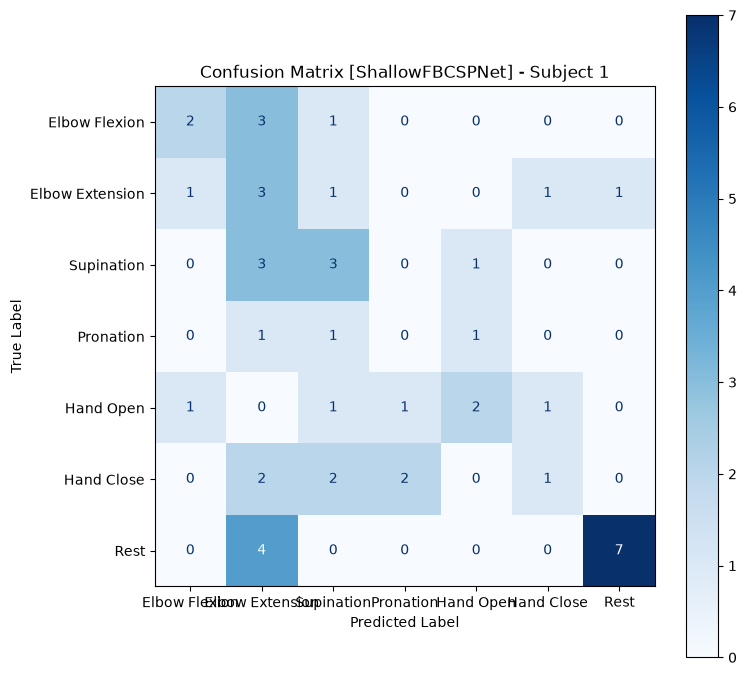

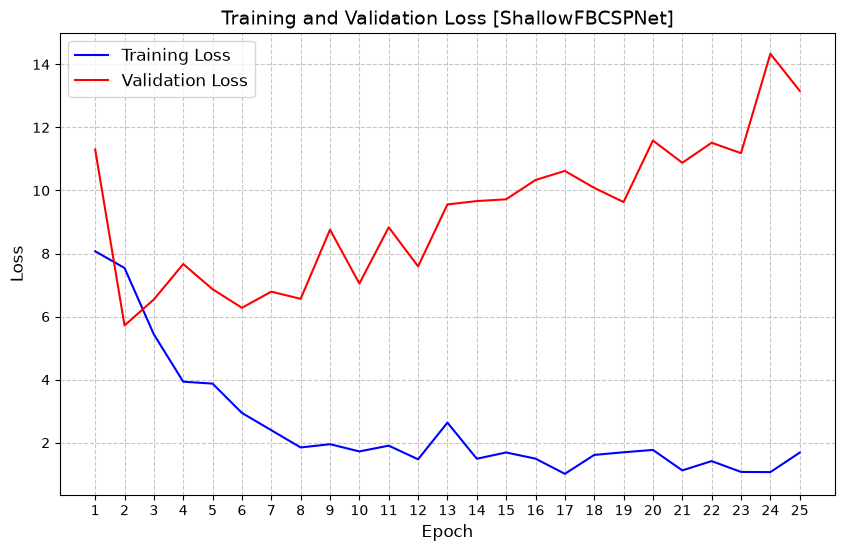

Finished training Subject 1.


In [ ]:
subject_id = 1
print(f"\n------ Setting up training for Subject {subject_id} ------")
train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    train_loss, val_loss = [], []
    best_val_accuracy = -float('inf')
    best_epoch = 0
    best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\{architecture}_{LEARNING_RATE}_{EPOCH_NUM}.pth')

    for epoch in range(EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(train_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            model.save_model(best_model_path)
            print(f'>>> Best model saved! Val Accuracy: {best_val_accuracy:.4f}% (Epoch {best_epoch})')

    print('\nBest Model:')
    print(f'\tEpoch: {best_epoch}')
    print(f'\tValidation Accuracy: {best_val_accuracy:.4f}%')
    print(f'\tSaved to: {best_model_path}')

    model.load_model(best_model_path)

    print('\nModel Final Accuracy (Best Validation Model):')
    print('\tTrain:', model.evaluate_accuracy(train_loader))
    print('\tTest:', model.evaluate_accuracy(test_loader))
    print('\tValidation:', model.evaluate_accuracy(val_loader))

    plot_confusion_matrix(
    model=model,
    data_loader=test_loader,
    class_names=classes,
    title=f'Confusion Matrix [{architecture}] - Subject {subject_id}')
    plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training Subject {subject_id}.")

## Pretraining


------ Setting up training for ALL Subjects ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Loading Subject 8 from cache...
Normalizing data based on training set statistics...
Loading Subject 9 from cache...
Normalizing data based on training set statistics...
Loading Subject 10 from cache...
Normalizing data based on training set statistics...
Loading Subject 11 from cache...
Normalizing data based on training set statistics...
Loading Sub

c:\Users\Diego\Documents\GitHub\EEG_Decoder_Robustness\.venv\Lib\site-packages\torch\nn\modules\conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1102.)
  return F.conv2d(


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 8, 61, 769]             512
       BatchNorm2d-2           [-1, 8, 61, 769]              16
            Conv2d-3           [-1, 16, 1, 769]             976
       BatchNorm2d-4           [-1, 16, 1, 769]              32
               ELU-5           [-1, 16, 1, 769]               0
         AvgPool2d-6           [-1, 16, 1, 192]               0
           Dropout-7           [-1, 16, 1, 192]               0
            Conv2d-8           [-1, 16, 1, 192]             256
            Conv2d-9           [-1, 16, 1, 192]             256
      BatchNorm2d-10           [-1, 16, 1, 192]              32
              ELU-11           [-1, 16, 1, 192]               0
        AvgPool2d-12            [-1, 16, 1, 24]               0
          Dropout-13            [-1, 16, 1, 24]               0
          Flatten-14                  [

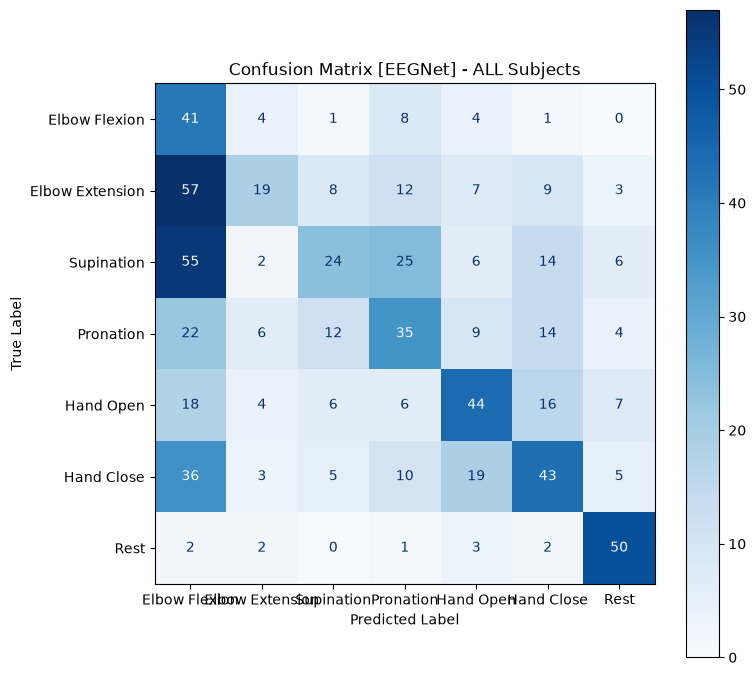

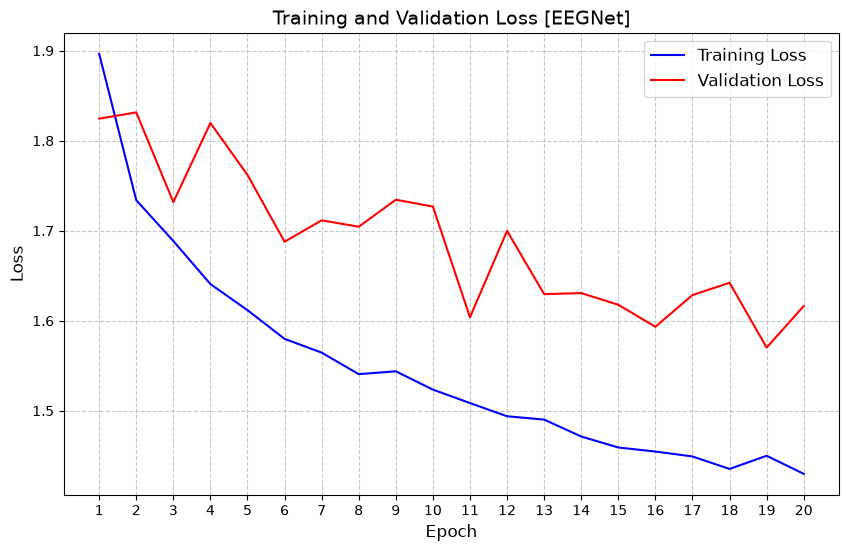

Selected Architecture: DeepConvNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100, 1, 72]             200
    

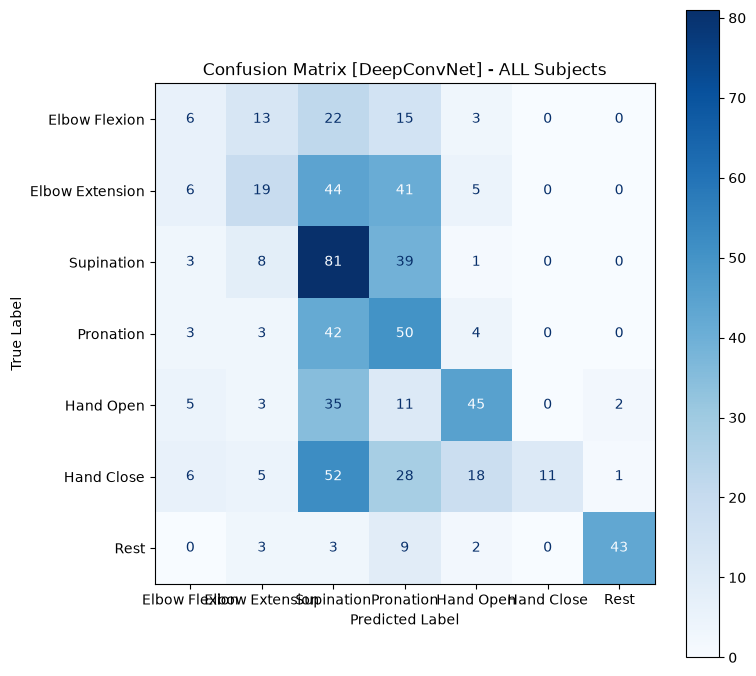

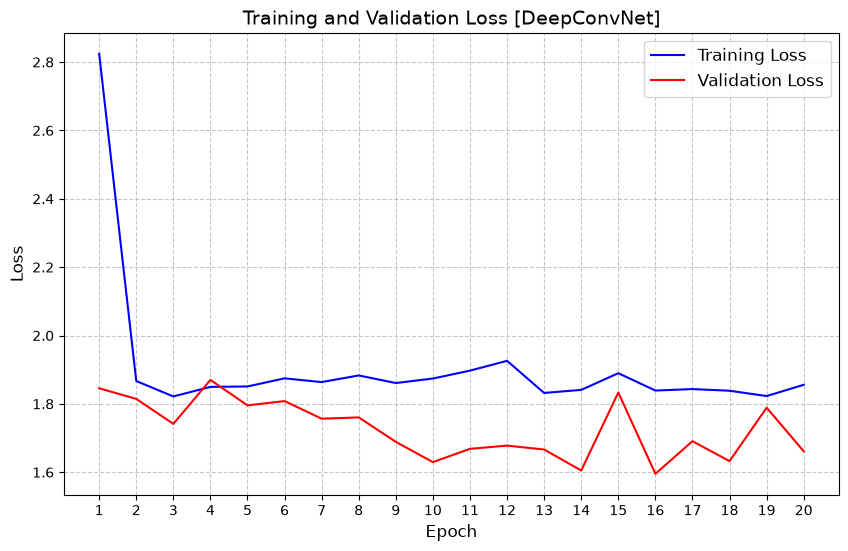

Selected Architecture: ShallowFBCSPNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 40, 61, 745]           1,000
            Conv2d-2           [-1, 40, 1, 745]          97,600
       BatchNorm2d-3           [-1, 40, 1, 745]              80
        Expression-4           [-1, 40, 1, 745]               0
         AvgPool2d-5            [-1, 40, 1, 45]               0
        Expression-6            [-1, 40, 1, 45]               0
           Dropout-7            [-1, 40, 1, 45]               0
           Flatten-8                 [-1, 1800]               0
            Linear-9                    [-1, 7]          12,607
Total params: 111,287
Trainable params: 111,287
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.18
Forward/backward pass size (MB): 14.61
Params size (MB): 0.42
Estimated Total Size (MB): 15.21
--

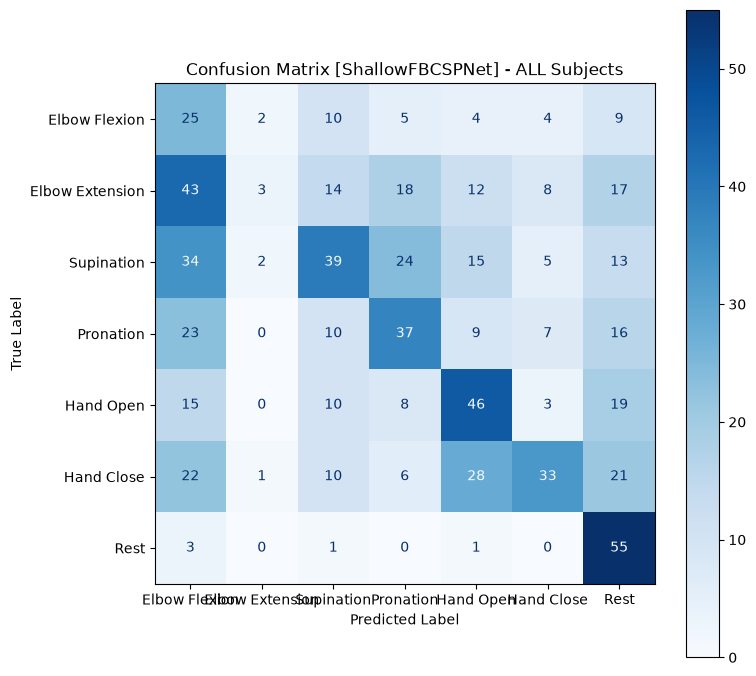

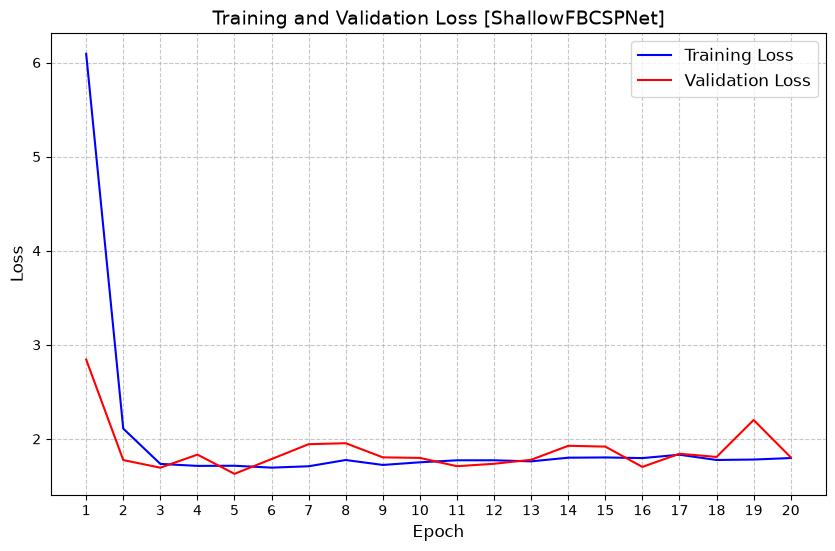

Selected Architecture: EEGNeX
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 8, 61, 769]             256
       BatchNorm2d-2           [-1, 8, 61, 769]              16
            Conv2d-3          [-1, 16, 61, 769]           4,096
       BatchNorm2d-4          [-1, 16, 61, 769]              32
            Conv2d-5           [-1, 32, 1, 769]           1,952
       BatchNorm2d-6           [-1, 32, 1, 769]              64
               ELU-7           [-1, 32, 1, 769]               0
         AvgPool2d-8           [-1, 32, 1, 192]               0
           Dropout-9           [-1, 32, 1, 192]               0
           Conv2d-10           [-1, 32, 1, 192]             512
      BatchNorm2d-11           [-1, 32, 1, 192]              64
              ELU-12           [-1, 32, 1, 192]               0
           Conv2d-13           [-1, 32, 1, 192]             512
      Bat

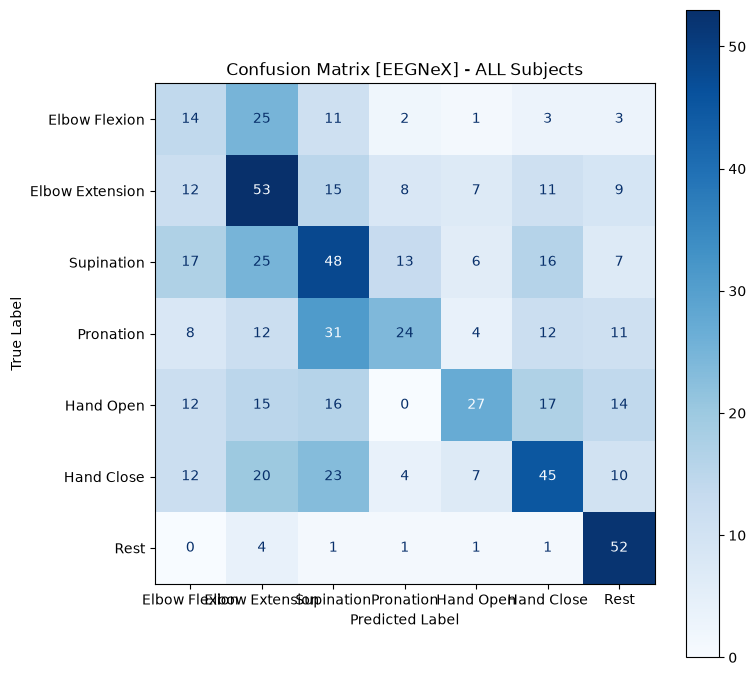

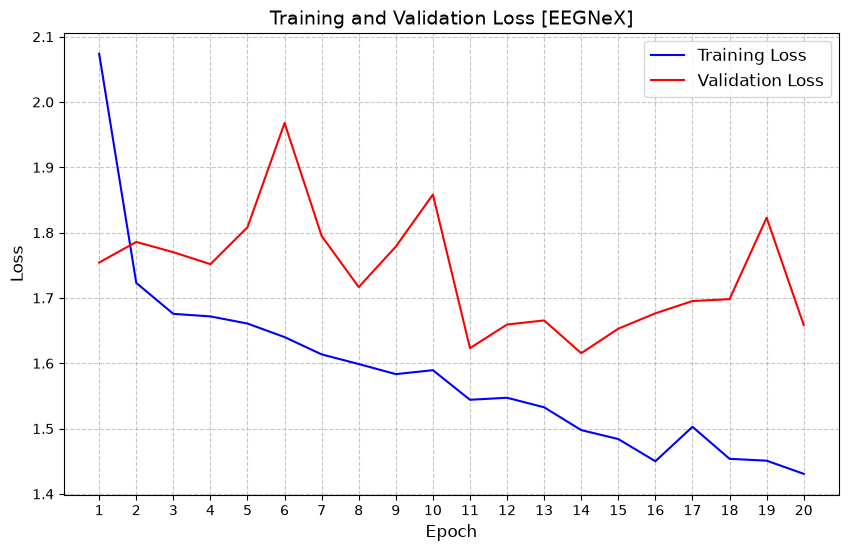

Selected Architecture: CTNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 16, 61, 769]             400
       BatchNorm2d-2          [-1, 16, 61, 769]              32
               ELU-3          [-1, 16, 61, 769]               0
            Conv2d-4           [-1, 32, 1, 769]           1,952
       BatchNorm2d-5           [-1, 32, 1, 769]              64
               ELU-6           [-1, 32, 1, 769]               0
         AvgPool2d-7           [-1, 32, 1, 192]               0
           Dropout-8           [-1, 32, 1, 192]               0
            Conv2d-9           [-1, 32, 1, 192]          15,360
      BatchNorm2d-10           [-1, 32, 1, 192]              64
              ELU-11           [-1, 32, 1, 192]               0
           Conv2d-12           [-1, 32, 1, 192]             480
      BatchNorm2d-13           [-1, 32, 1, 192]              64
          

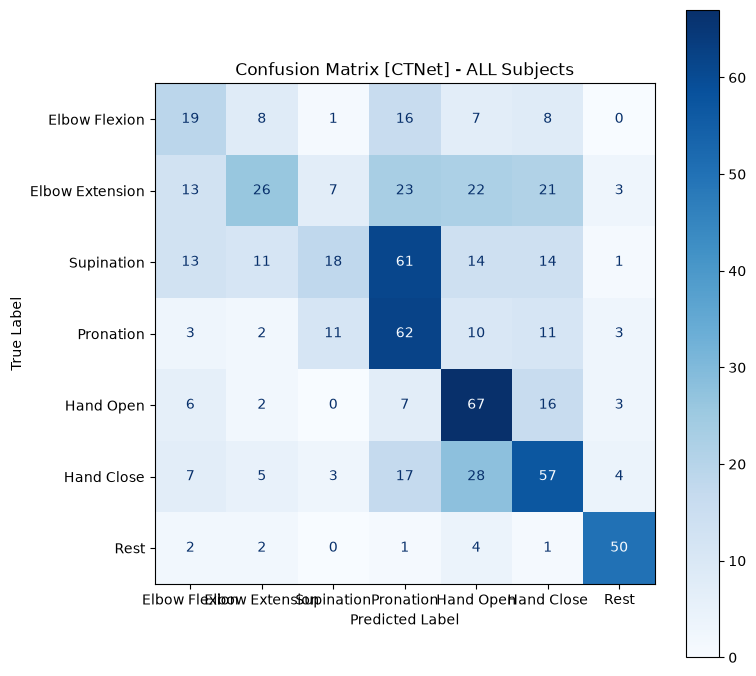

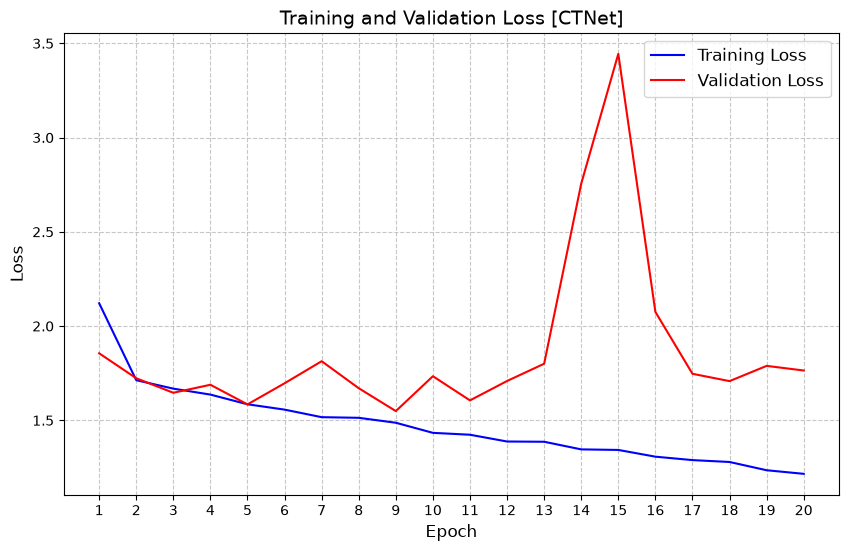

Selected Architecture: Deep4Net
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100, 1, 72]             200
       

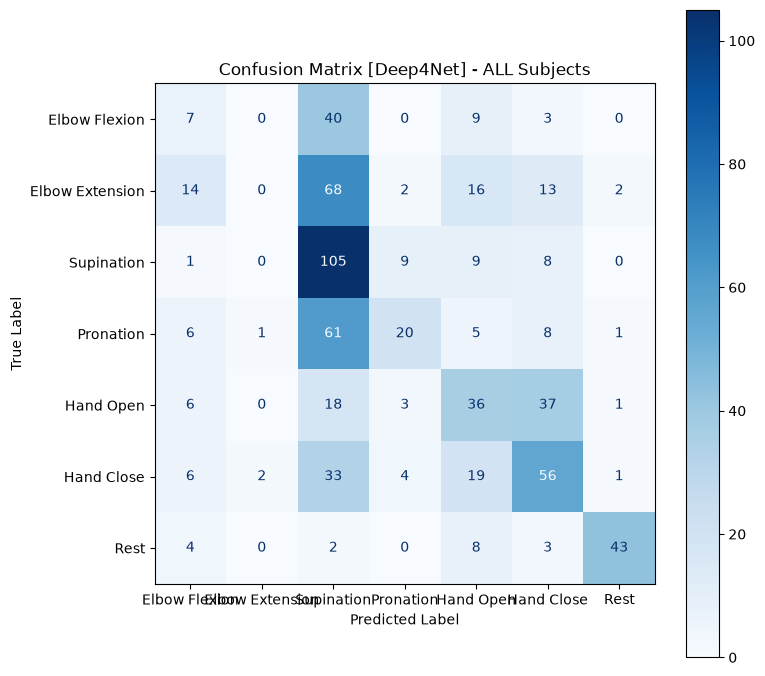

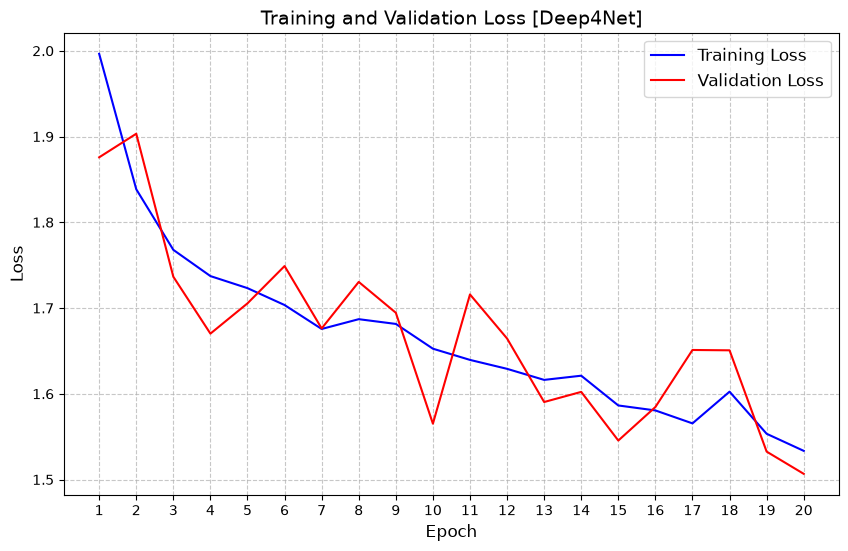

Finished training.


In [10]:
print(f"\n------ Setting up training for ALL Subjects ------")
subjects=[i + 1 for i in range(SUBJECT_COUNT)]
full_train_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED)
full_val_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED, train=False)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=P_LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    train_loss, val_loss = [], []
    model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}.pth')

    for epoch in range(P_EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(full_train_loader, full_val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(full_train_loader)
        val_acc = model.evaluate_accuracy(full_val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

    model.save_model(model_path)

    print('\nModel Final Accuracy:')
    print('\tTrain:', model.evaluate_accuracy(full_train_loader))
    print('\tValidation:', model.evaluate_accuracy(full_val_loader))

    plot_confusion_matrix(
        model=model,
        data_loader=full_val_loader,
        class_names=classes,
        title=f'Confusion Matrix [{architecture}] - ALL Subjects'
    )
    plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training.")

## Fine-tunning

#################### Selected Architecture: EEGNet ####################
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Subject #1:	Test Acc: 53.1915	Validation Acc: 54.3478
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Subject #2:	Test Acc: 51.0638	Validation Acc: 47.8261
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Subject #3:	Test Acc: 82.9787	Validation Acc: 100.0000
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Subject #4:	Test Acc: 78.7234	Validation Acc: 95.6522
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Subject #5:	Test Acc: 46.8085	Validation Acc: 52.1739
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Subject #6:	Test Acc: 63.8298	Validation Acc: 56.5217
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Subject 

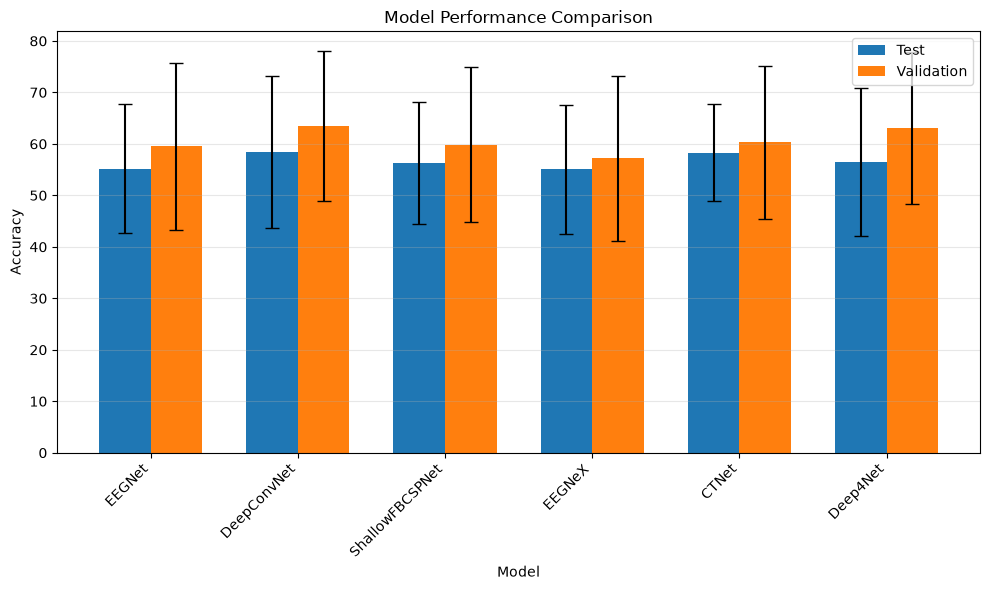

In [11]:
test_mean, test_var, val_mean, val_var = [], [], [], []
for architecture in MODEL_ARCHITECTURES:
    print('#' * 20, 'Selected Architecture:', architecture, '#' * 20)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    test_accs, val_accs = [], []
    for subject_id in range(1, 1 + SUBJECT_COUNT):
        train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)
        pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}.pth')
        model.load_model(pretrained_model_path, verbose=False)
        best_val_accuracy = -float('inf')
        best_epoch = 0
        best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_{architecture}_{LEARNING_RATE}_{EPOCH_NUM}.pth')
        for epoch in range(EPOCH_NUM):
            t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
            val_acc = model.evaluate_accuracy(val_loader)
            if val_acc > best_val_accuracy:
                best_val_accuracy = val_acc
                best_epoch = epoch + 1
                model.save_model(best_model_path, verbose=False)
        
        model.load_model(best_model_path, verbose=False)
        test_acc = model.evaluate_accuracy(test_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        test_accs.append(test_acc)
        val_accs.append(val_acc)
        print(f'Subject #{subject_id}:\tTest Acc: {test_acc:.4f}\tValidation Acc: {val_acc:.4f}')
    test_mean.append(np.mean(test_accs))
    test_var.append(np.var(test_accs))
    val_mean.append(np.mean(val_accs))
    val_var.append(np.var(val_accs))
    print('Results for Model Accuracy')
    print(f'Validation: ~N({test_mean[-1]:.3f}, {test_var[-1]:.3f}), Test: ~N({val_mean[-1]:.3f}, {val_var[-1]:.3f})\n')
plot_model_performance(MODEL_ARCHITECTURES, test_mean, test_var, val_mean, val_var)


------ Setting up training for Subject 1 ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Selected Architecture: EEGNet
Model loaded successfully from .\Models\Pretrained\EEGNet_0.02_20.pth
Epoch#1 ==== train acc: 58.5366, train loss: 1.4795 ==== val acc: 39.1304, val loss: 1.5978
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 39.1304% (Epoch 1)
Epoch#2 ==== train acc: 66.3957, train loss: 1.2866 ==== val acc: 41.3043, val loss: 1.5389
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 41.3043% (Epoch 2)
Epoch#3 ==== train acc: 70.7317, train loss: 1.1276 ==== val acc: 43.4783, val loss: 1.4564
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 43.4783% (Epoch 3)
Epoch#4 ==== train acc: 74.5257, train loss: 0.9796 ==== val acc: 47.8261, val loss: 1.4954
Model

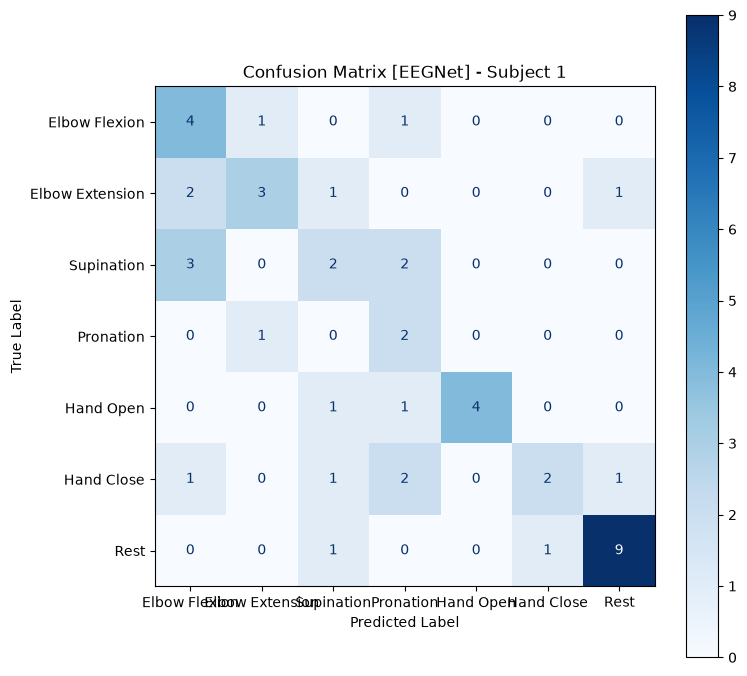

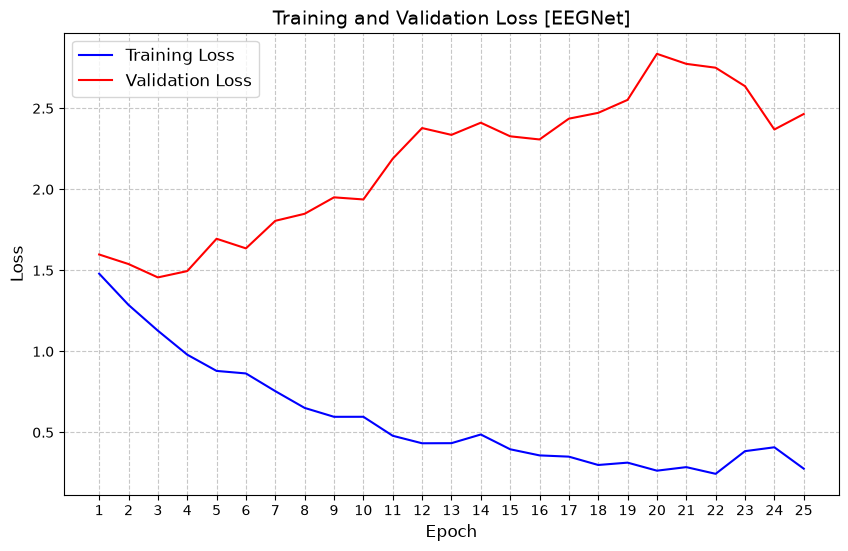

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Pretrained\DeepConvNet_0.02_20.pth
Epoch#1 ==== train acc: 46.6125, train loss: 2.0133 ==== val acc: 36.9565, val loss: 1.5558
Model saved successfully to .\Models\Subject 1\Finetuned_DeepConvNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 60.4336, train loss: 1.6281 ==== val acc: 50.0000, val loss: 1.3952
Model saved successfully to .\Models\Subject 1\Finetuned_DeepConvNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 50.0000% (Epoch 2)
Epoch#3 ==== train acc: 62.8726, train loss: 1.4632 ==== val acc: 47.8261, val loss: 1.3240
Epoch#4 ==== train acc: 60.7046, train loss: 1.4384 ==== val acc: 39.1304, val loss: 1.6224
Epoch#5 ==== train acc: 65.3117, train loss: 1.3221 ==== val acc: 43.4783, val loss: 1.3448
Epoch#6 ==== train acc: 69.9187, train loss: 1.2272 ==== val acc: 45.6522, val loss: 1.3297
Epoch#7 ==== train acc: 66.6667, train loss: 1.1743 ==== val acc: 

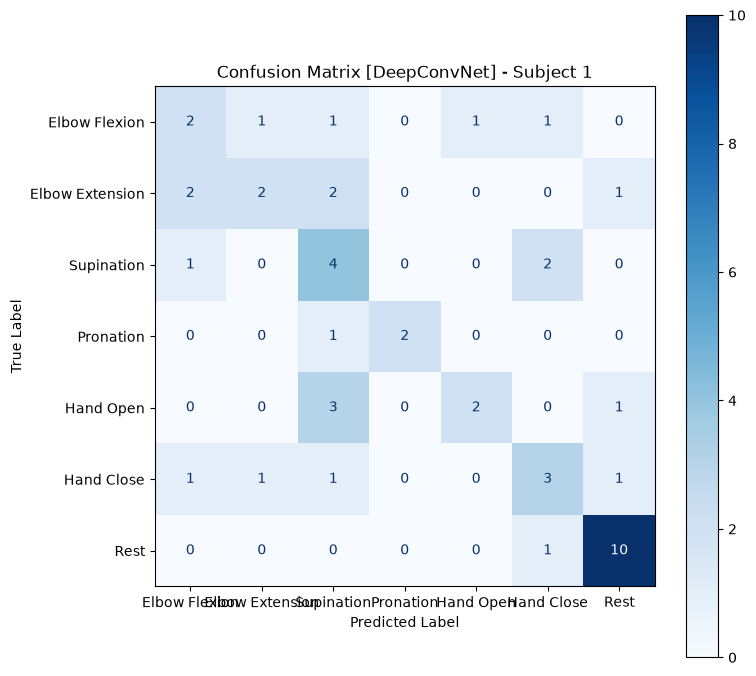

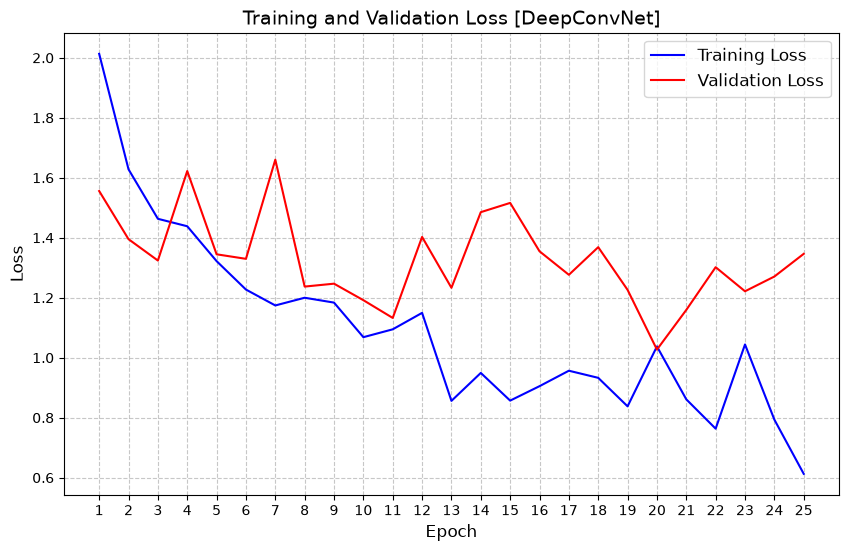

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Pretrained\ShallowFBCSPNet_0.02_20.pth
Epoch#1 ==== train acc: 67.7507, train loss: 1.6376 ==== val acc: 36.9565, val loss: 1.5960
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 73.9837, train loss: 1.3302 ==== val acc: 47.8261, val loss: 1.4361
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 47.8261% (Epoch 2)
Epoch#3 ==== train acc: 75.8808, train loss: 1.2437 ==== val acc: 45.6522, val loss: 1.5177
Epoch#4 ==== train acc: 77.2358, train loss: 1.0443 ==== val acc: 45.6522, val loss: 1.5878
Epoch#5 ==== train acc: 92.4119, train loss: 0.8092 ==== val acc: 56.5217, val loss: 1.4981
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 56.5217% (Epoch 5)
Ep

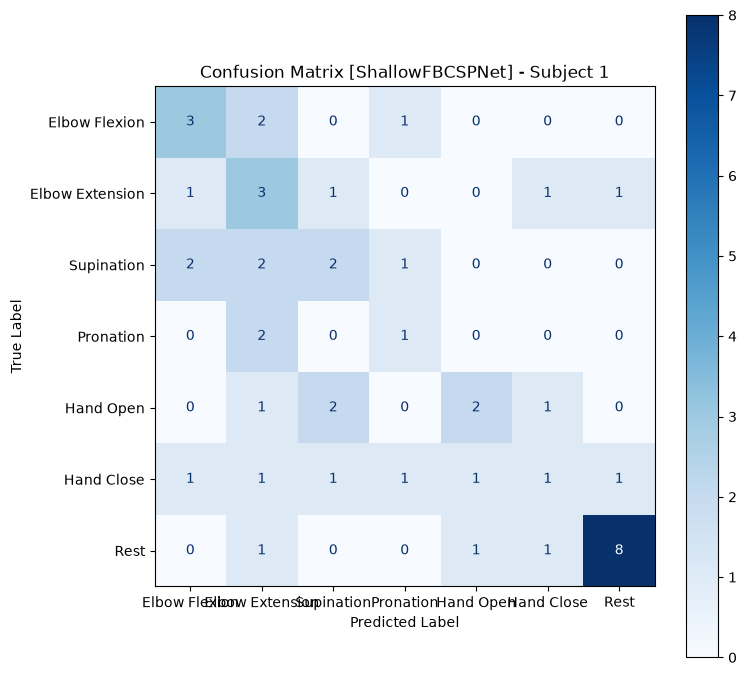

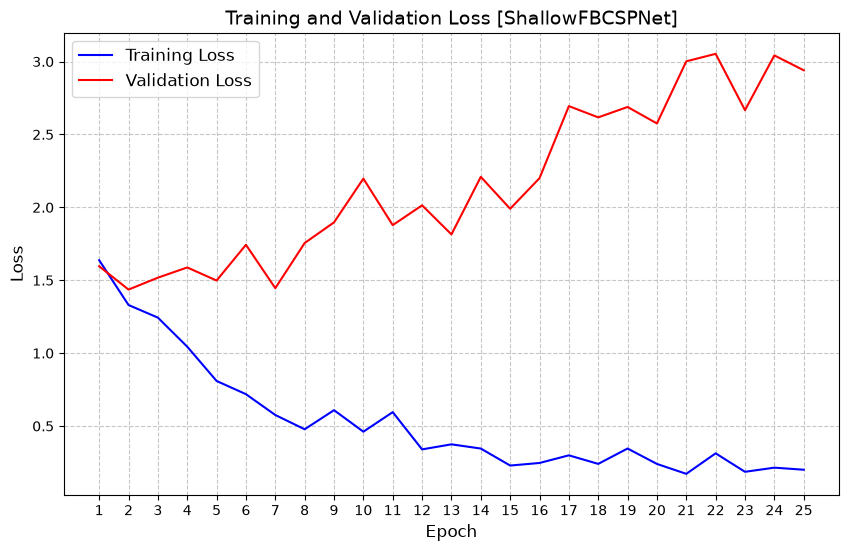

Selected Architecture: EEGNeX
Model loaded successfully from .\Models\Pretrained\EEGNeX_0.02_20.pth
Epoch#1 ==== train acc: 68.0217, train loss: 1.4664 ==== val acc: 36.9565, val loss: 1.5128
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNeX_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 78.3198, train loss: 1.0548 ==== val acc: 45.6522, val loss: 1.5988
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNeX_0.01_25.pth
>>> Best model saved! Val Accuracy: 45.6522% (Epoch 2)
Epoch#3 ==== train acc: 83.4688, train loss: 0.8997 ==== val acc: 34.7826, val loss: 1.9982
Epoch#4 ==== train acc: 91.3279, train loss: 0.7523 ==== val acc: 45.6522, val loss: 1.8235
Epoch#5 ==== train acc: 96.2060, train loss: 0.5638 ==== val acc: 45.6522, val loss: 1.9253
Epoch#6 ==== train acc: 95.3930, train loss: 0.5565 ==== val acc: 50.0000, val loss: 1.8290
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNeX_0.01_25.pth
>>> Best m

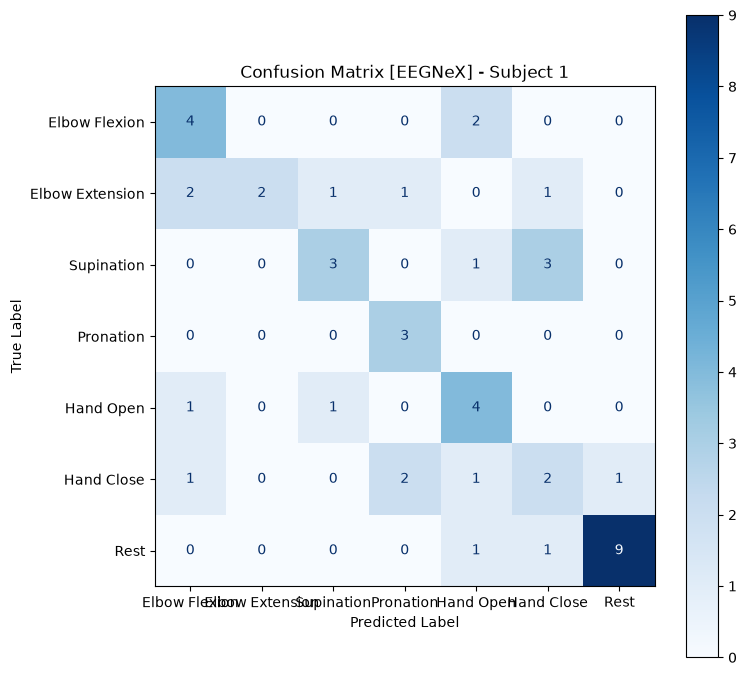

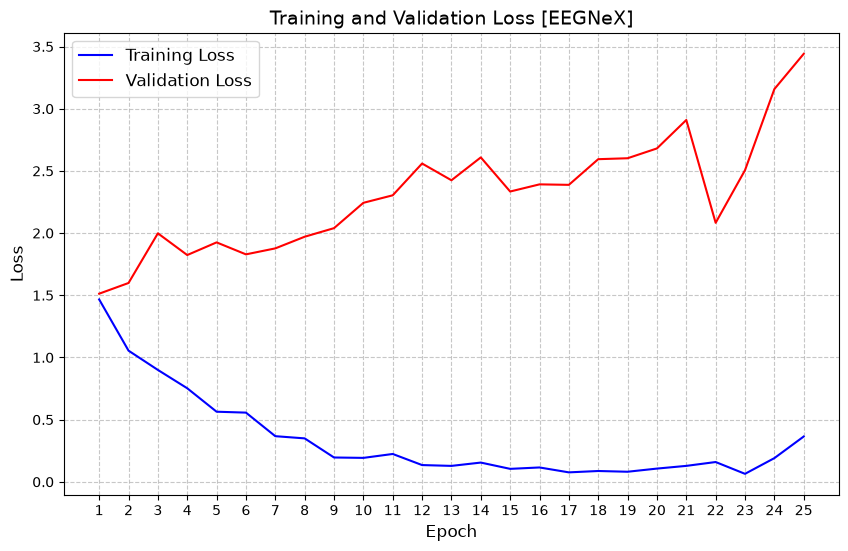

Selected Architecture: CTNet
Model loaded successfully from .\Models\Pretrained\CTNet_0.02_20.pth
Epoch#1 ==== train acc: 81.3008, train loss: 1.1908 ==== val acc: 47.8261, val loss: 1.7504
Model saved successfully to .\Models\Subject 1\Finetuned_CTNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 47.8261% (Epoch 1)
Epoch#2 ==== train acc: 94.5799, train loss: 0.6866 ==== val acc: 47.8261, val loss: 1.6856
Epoch#3 ==== train acc: 96.2060, train loss: 0.4862 ==== val acc: 54.3478, val loss: 1.5479
Model saved successfully to .\Models\Subject 1\Finetuned_CTNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 54.3478% (Epoch 3)
Epoch#4 ==== train acc: 97.8320, train loss: 0.3672 ==== val acc: 52.1739, val loss: 1.9114
Epoch#5 ==== train acc: 98.3740, train loss: 0.3119 ==== val acc: 54.3478, val loss: 1.7414
Epoch#6 ==== train acc: 100.0000, train loss: 0.1646 ==== val acc: 56.5217, val loss: 2.0317
Model saved successfully to .\Models\Subject 1\Finetuned_CTNet_0.01_25.pth
>>> Best model

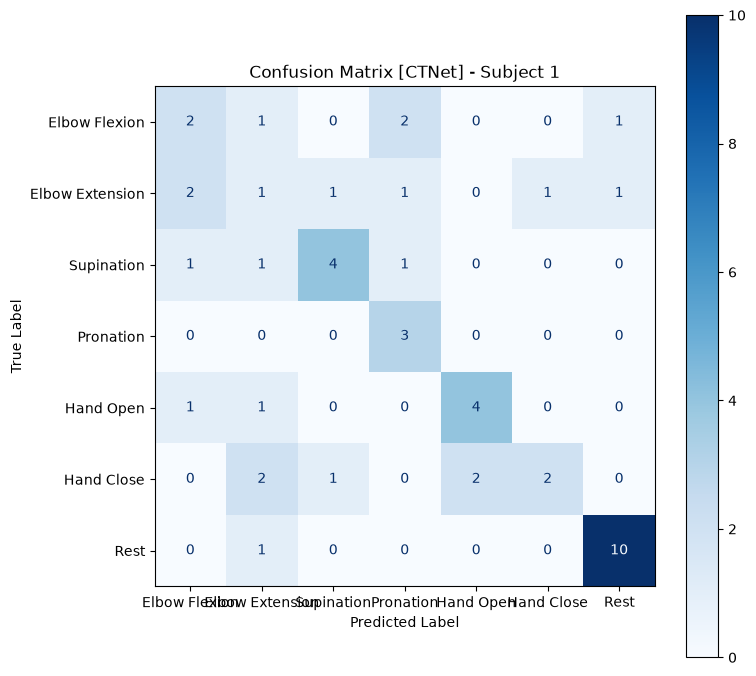

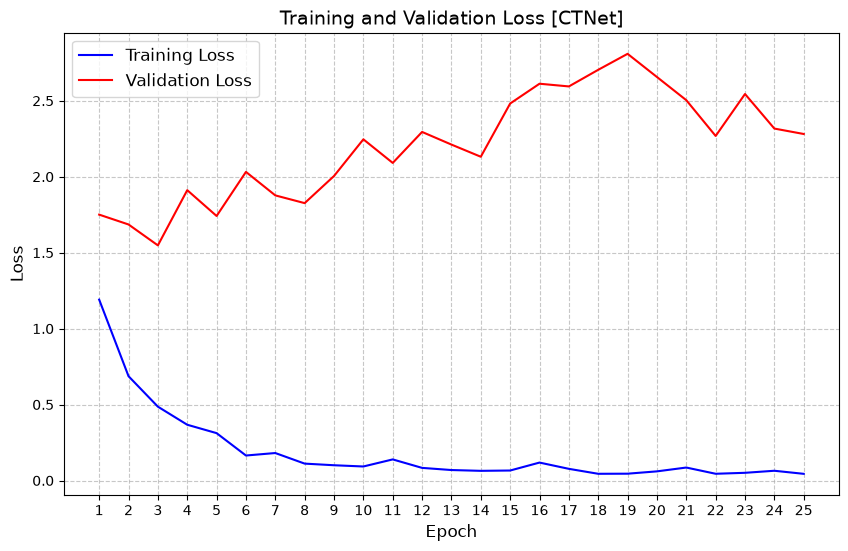

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Pretrained\Deep4Net_0.02_20.pth
Epoch#1 ==== train acc: 53.9295, train loss: 1.6248 ==== val acc: 36.9565, val loss: 1.4942
Model saved successfully to .\Models\Subject 1\Finetuned_Deep4Net_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 53.1165, train loss: 1.3907 ==== val acc: 41.3043, val loss: 1.4476
Model saved successfully to .\Models\Subject 1\Finetuned_Deep4Net_0.01_25.pth
>>> Best model saved! Val Accuracy: 41.3043% (Epoch 2)
Epoch#3 ==== train acc: 66.3957, train loss: 1.4400 ==== val acc: 45.6522, val loss: 1.2713
Model saved successfully to .\Models\Subject 1\Finetuned_Deep4Net_0.01_25.pth
>>> Best model saved! Val Accuracy: 45.6522% (Epoch 3)
Epoch#4 ==== train acc: 63.4146, train loss: 1.2734 ==== val acc: 39.1304, val loss: 1.3072
Epoch#5 ==== train acc: 66.9377, train loss: 1.2956 ==== val acc: 50.0000, val loss: 1.2985
Model saved successfully to .\Models\

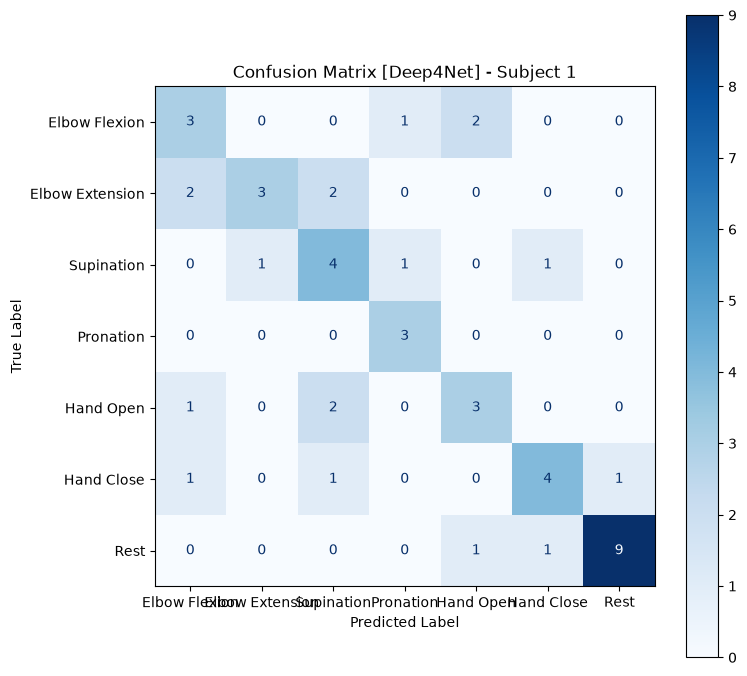

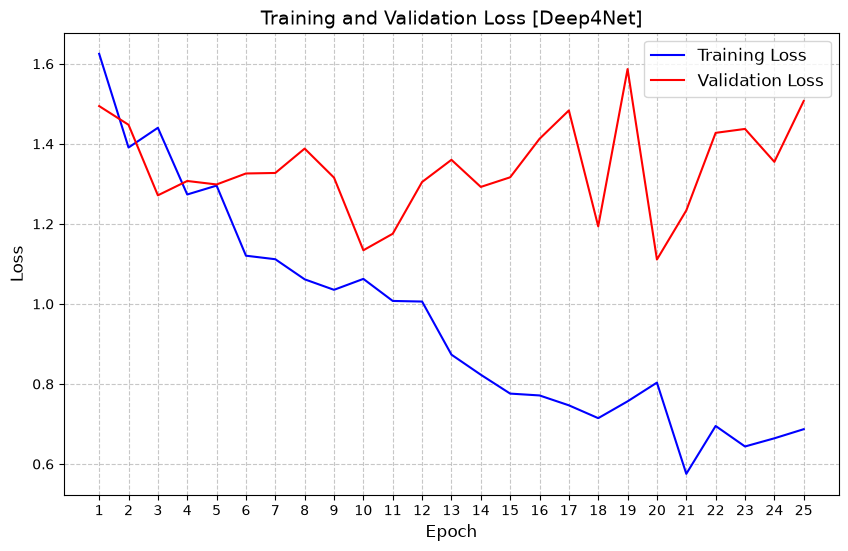

Finished training Subject 1.


In [ ]:
subject_id = 1
print(f"\n------ Setting up training for Subject {subject_id} ------")
train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}.pth')
    model.load_model(pretrained_model_path)
    train_loss, val_loss = [], []
    best_val_accuracy = -float('inf')
    best_epoch = 0
    best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_{architecture}_{LEARNING_RATE}_{EPOCH_NUM}.pth')

    for epoch in range(EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(train_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            model.save_model(best_model_path)
            print(f'>>> Best model saved! Val Accuracy: {best_val_accuracy:.4f}% (Epoch {best_epoch})')

    print('\nBest Model:')
    print(f'\tEpoch: {best_epoch}')
    print(f'\tValidation Accuracy: {best_val_accuracy:.4f}%')
    print(f'\tSaved to: {best_model_path}')

    model.load_model(best_model_path)

    print('\nModel Final Accuracy (Best Validation Model):')
    print('\tTrain:', model.evaluate_accuracy(train_loader))
    print('\tTest:', model.evaluate_accuracy(test_loader))
    print('\tValidation:', model.evaluate_accuracy(val_loader))

    plot_confusion_matrix(
    model=model,
    data_loader=test_loader,
    class_names=classes,
    title=f'Confusion Matrix [{architecture}] - Subject {subject_id}')
    plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training Subject {subject_id}.")